Рунге-Кутта:
Абсолютная погрешность: 0.00043362773388282215
Относительная погрешность: 0.000233142128197306

Адамса:
Абсолютная погрешность: 0.09474469526053805
Относительная погрешность: 0.08437370998194484



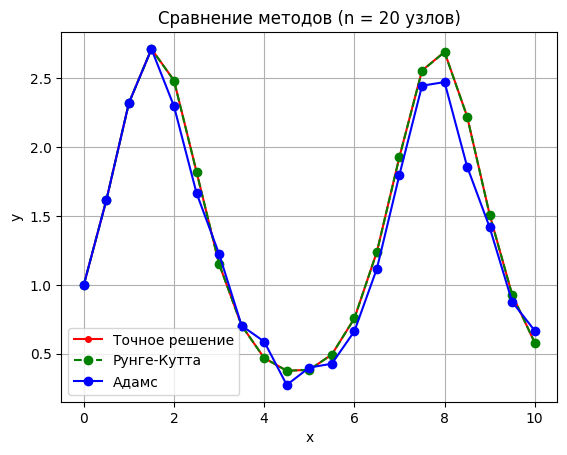

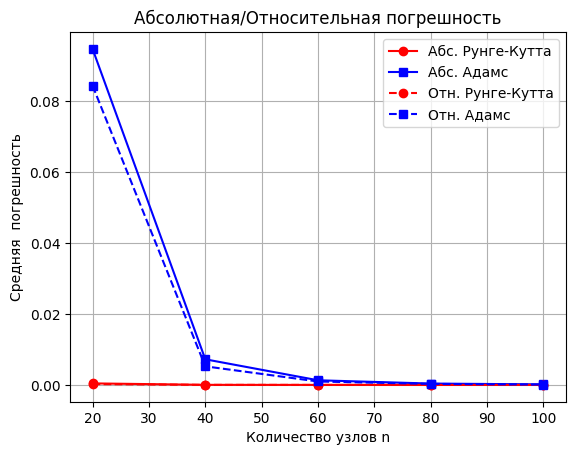

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return y * np.cos(x)

def y_exat(x):
    return np.exp(np.sin(x))

def RK_4 (f, x0, y0, h, n):
    x = np.zeros(n + 1)
    y = np.zeros(n + 1)

    x[0] = x0
    y[0] = y0

    for i in range(n):
        k0 = f(x[i], y[i])
        k1 = f(x[i] + h/2, y[i] + h/2 * k0)
        k2 = f(x[i] + h/2, y[i] + h/2 * k1)
        k3 = f(x[i] + h, y[i] + h * k2)

        y[i + 1] = y[i] + h/6 * (k0 + 2*k1 + 2*k2 + k3) 
        x[i + 1] = x[i] + h 

    return x, y
    
def Adams_4(f, x0, y0, h, n):
    x = np.zeros(n + 1)
    y = np.zeros(n + 1)

    x[:4], y[:4] = RK_4(f, x0, y0, h, 3)

    # Вычисляем f в первых точках
    f_vals = np.zeros(n + 1)
    for i in range(4):
        f_vals[i] = f(x[i], y[i])

    for i in range(3, n):
        y[i + 1] = y[i] + h/24 * (55 * f_vals[i] - 59 * f_vals[i-1] + 37 * f_vals[i-2] - 9 * f_vals[i-3])
        x[i + 1] = x[i] + h
        f_vals[i + 1] = f(x[i + 1], y[i + 1])

    return x, y

def pogresh (y_ch, y_toch):
    absolut = np.mean(np.abs(y_ch - y_toch))
    otnositel = np.mean(np.abs(y_ch - y_toch) / (np.abs(y_toch)))
    return absolut, otnositel


a, b = 0, 10
n = 20
h = (b - a) / n

x_RK, y_RK = RK_4(f, a, 1.0, h, n)
x_A, y_A = Adams_4(f, a, 1.0, h, n)
y_toch = y_exat(x_RK)

abs_RK, otn_RK = pogresh(y_RK, y_toch)
abs_A, otn_A = pogresh(y_A, y_toch)

print('Рунге-Кутта:')
print(f'''Абсолютная погрешность: {abs_RK}
Относительная погрешность: {otn_RK}''')
print()
print('Адамса:')
print(f'''Абсолютная погрешность: {abs_A}
Относительная погрешность: {otn_A}''')
print()

plt.figure(1)
plt.plot(x_RK, y_toch, 'ro-', label='Точное решение', markersize=4)
plt.plot(x_RK, y_RK, 'go--', label='Рунге-Кутта')
plt.plot(x_A, y_A, 'bo-', label='Адамс')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение методов (n = 20 узлов)')
plt.legend()
plt.grid()


val_N = [20, 40, 60, 80, 100]
mass_abs_RK = []
mass_otn_RK = []
mass_abs_A = []
mass_otn_A = []

for n_uz in val_N:
    h_t = (b - a) / n_uz
    _, y_rk_tek = RK_4(f, a, 1.0, h_t, n_uz)
    _, y_ad_tek = Adams_4(f, a, 1.0, h_t, n_uz)

    x_tek = np.linspace(a, b, n_uz + 1)
    y_toch_tek = y_exat(x_tek)

    abs_rk_tek, otn_rk_tek = pogresh(y_rk_tek, y_toch_tek)
    abs_a_tek, otn_a_tek = pogresh(y_ad_tek, y_toch_tek)

    mass_abs_RK.append(abs_rk_tek)
    mass_abs_A.append(abs_a_tek)
    mass_otn_A.append(otn_a_tek)
    mass_otn_RK.append(otn_rk_tek)


plt.figure(2)

plt.plot(val_N, mass_abs_RK, 'ro-', label='Абс. Рунге-Кутта')
plt.plot(val_N, mass_abs_A, 'bs-', label='Абс. Адамс')
plt.plot(val_N, mass_otn_RK, 'ro--', label='Отн. Рунге-Кутта')
plt.plot(val_N, mass_otn_A, 'bs--', label='Отн. Адамс')
plt.xlabel('Количество узлов n')
plt.ylabel('Средняя  погрешность')
plt.title('Абсолютная/Относительная погрешность')
plt.legend()
plt.grid()

plt.show()